In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Directories
PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
LOG_FILE = os.path.join(OUTPUT_DIR, "Descriptive_Analytics_Log.txt")

os.makedirs(FIGURES_DIR, exist_ok=True)

# Clear log file
with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS DESCRIPTIVE ANALYTICS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")

# Load datasets
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_scored.csv"))
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_scored.csv"))
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_scored.csv"))

df_orig = df_orig.dropna(subset=['codebert_score', 'adak_index']).copy()

# Add comment word count for analysis
df_orig['comment_word_count'] = df_orig['comment'].apply(lambda x: len(str(x).split()))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})

log_result("Data loaded successfully. Output directories mapped.")

Data loaded successfully. Output directories mapped.


In [2]:
log_result(f"\n{'='*50}\n1. Dataset Summary Statistics\n{'='*50}")

# Select the core numerical columns
columns_to_describe =['code_token_length', 'comment_word_count', 'mcv', 'sfv', 'adak_index', 'codebert_score']
summary_stats = df_orig[columns_to_describe].describe().round(4)

log_result(summary_stats.to_string())

# Save to CSV for easy import into Word/Excel
summary_csv_path = os.path.join(OUTPUT_DIR, "Table_Summary_Statistics.csv")
summary_stats.to_csv(summary_csv_path)
log_result(f"\nSummary statistics saved to: {summary_csv_path}")


1. Dataset Summary Statistics
       code_token_length  comment_word_count         mcv         sfv  adak_index  codebert_score
count         12000.0000          12000.0000  12000.0000  12000.0000  12000.0000      12000.0000
mean             96.6532             29.8131      4.1989     23.1374    144.9685          0.9598
std              82.8379             48.6418      6.6804     24.4346    665.5459          0.0264
min              17.0000              1.0000      0.8000      0.3000    -99.5916          0.7985
25%              42.0000              8.0000      0.8000      8.7000    -94.2029          0.9482
50%              67.0000             16.0000      2.4000     15.9000    -85.4545          0.9679
75%             118.0000             34.0000      4.8000     29.4000    -44.6541          0.9780
max             511.0000           1472.0000    226.4000    195.9000  16166.6667          0.9998

Summary statistics saved to: C:\Users\HP\Desktop\thesis_preprocessing\outputs\Table_Summary_Sta


2. Code vs. Comment Volume Correlation
Pearson Correlation (SFV vs MCV): 0.0501 (p-value: 3.9440e-08)


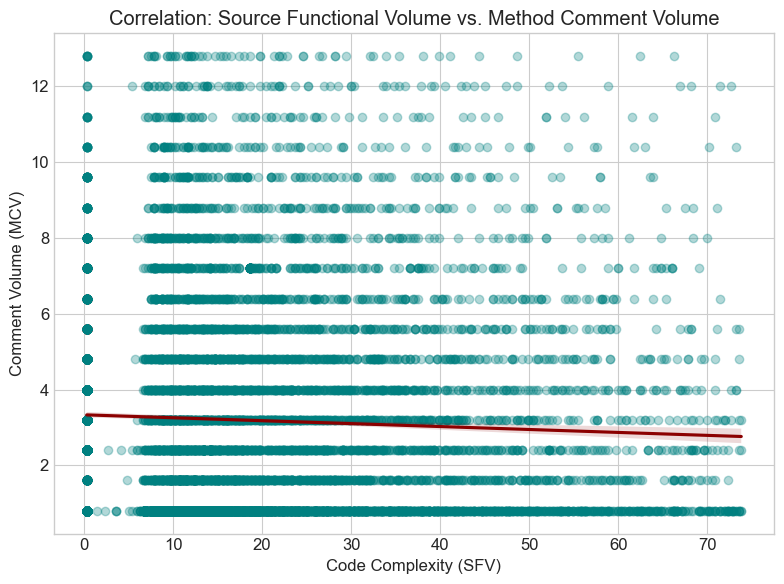

In [3]:
log_result(f"\n{'='*50}\n2. Code vs. Comment Volume Correlation\n{'='*50}")

# Calculate Pearson Correlation between Code Volume (SFV) and Comment Volume (MCV)
pearson_corr, p_val = stats.pearsonr(df_orig['sfv'], df_orig['mcv'])
log_result(f"Pearson Correlation (SFV vs MCV): {pearson_corr:.4f} (p-value: {p_val:.4e})")

plt.figure(figsize=(8, 6))

# Filter extreme outliers for visualization purposes (95th percentile)
sfv_cap = df_orig['sfv'].quantile(0.95)
mcv_cap = df_orig['mcv'].quantile(0.95)
filtered_length_df = df_orig[(df_orig['sfv'] <= sfv_cap) & (df_orig['mcv'] <= mcv_cap)]

sns.regplot(data=filtered_length_df, x='sfv', y='mcv', 
            scatter_kws={'alpha':0.3, 'color': 'teal'}, line_kws={'color': 'darkred'})

plt.title('Correlation: Source Functional Volume vs. Method Comment Volume')
plt.xlabel('Code Complexity (SFV)')
plt.ylabel('Comment Volume (MCV)')
plt.tight_layout()

output_fig = os.path.join(FIGURES_DIR, "EDA_SFV_vs_MCV_Scatter.png")
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()


3. Semantic Ground Truth Validation (CodeBERT Distributions)


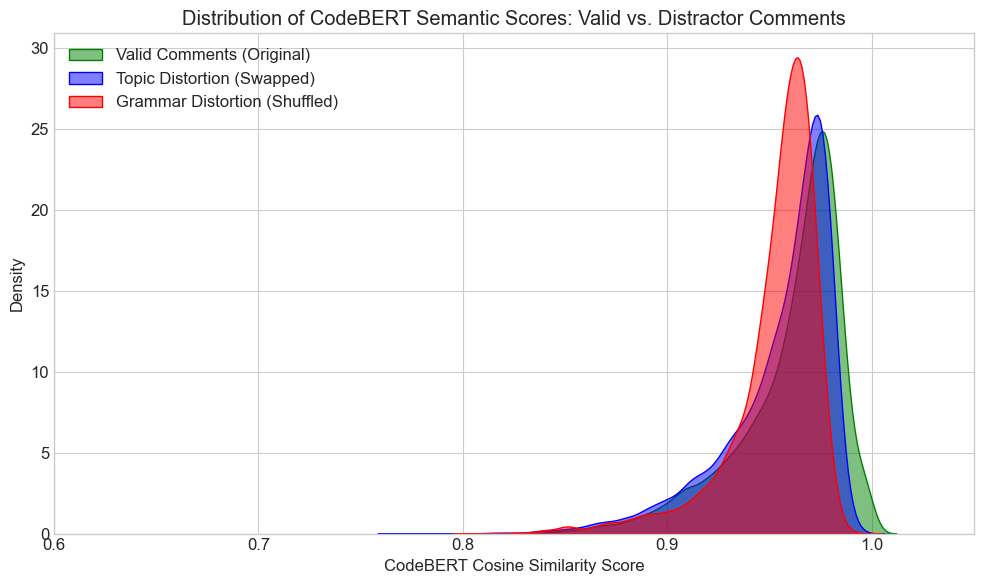

Mean CodeBERT Score (Valid):    0.9598
Mean CodeBERT Score (Swapped):  0.9544
Mean CodeBERT Score (Shuffled): 0.9523


In [4]:
log_result(f"\n{'='*50}\n3. Semantic Ground Truth Validation (CodeBERT Distributions)\n{'='*50}")

plt.figure(figsize=(10, 6))

# Plot KDE (Kernel Density Estimate) for all three datasets
sns.kdeplot(df_orig['codebert_score'], fill=True, color='green', label='Valid Comments (Original)', alpha=0.5)
sns.kdeplot(df_dist_a['codebert_score'], fill=True, color='blue', label='Topic Distortion (Swapped)', alpha=0.5)
sns.kdeplot(df_dist_b['codebert_score'], fill=True, color='red', label='Grammar Distortion (Shuffled)', alpha=0.5)

plt.title('Distribution of CodeBERT Semantic Scores: Valid vs. Distractor Comments')
plt.xlabel('CodeBERT Cosine Similarity Score')
plt.ylabel('Density')
plt.legend(loc='upper left')
plt.xlim(0.6, 1.05) # CodeBERT cosine similarities generally fall in the upper range

plt.tight_layout()
output_fig = os.path.join(FIGURES_DIR, "EDA_CodeBERT_Distributions.png")
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()

# Log the mean CodeBERT scores
log_result(f"Mean CodeBERT Score (Valid):    {df_orig['codebert_score'].mean():.4f}")
log_result(f"Mean CodeBERT Score (Swapped):  {df_dist_a['codebert_score'].mean():.4f}")
log_result(f"Mean CodeBERT Score (Shuffled): {df_dist_b['codebert_score'].mean():.4f}")


4. Adak Index Distribution


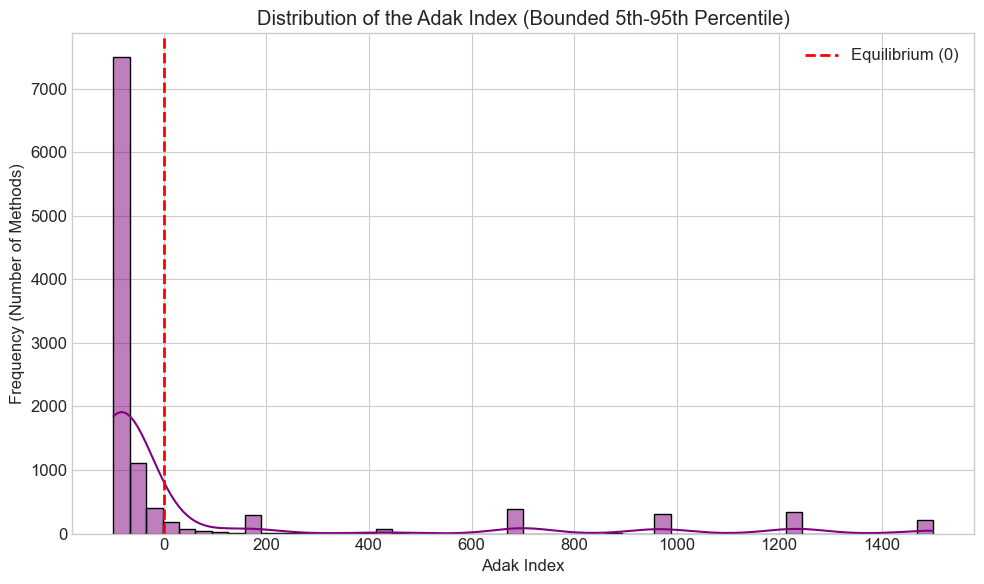

Adak Index Skewness: 5.9206 (Highly right-skewed indicates extreme outliers)


In [5]:
log_result(f"\n{'='*50}\n4. Adak Index Distribution\n{'='*50}")

plt.figure(figsize=(10, 6))

# Cap at 5th and 95th percentiles to avoid the graph being ruined by extreme outliers
adak_lower = df_orig['adak_index'].quantile(0.05)
adak_upper = df_orig['adak_index'].quantile(0.95)
filtered_adak = df_orig[(df_orig['adak_index'] >= adak_lower) & (df_orig['adak_index'] <= adak_upper)]

sns.histplot(filtered_adak['adak_index'], bins=50, kde=True, color='purple')

plt.title('Distribution of the Adak Index (Bounded 5th-95th Percentile)')
plt.xlabel('Adak Index')
plt.ylabel('Frequency (Number of Methods)')
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Equilibrium (0)')
plt.legend()

plt.tight_layout()
output_fig = os.path.join(FIGURES_DIR, "EDA_Adak_Index_Distribution.png")
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()

log_result(f"Adak Index Skewness: {df_orig['adak_index'].skew():.4f} (Highly right-skewed indicates extreme outliers)")